## Introduction

- Finding the right talent for technology companies is a challenging and resource-intensive task. Recruiters must not only understand the client’s requirements but also identify what makes a candidate stand out and where to locate such individuals. This manual process consumes significant time and effort, often slowing down the hiring pipeline.

- To streamline this process, we are developing a machine learning–powered solution that automates candidate evaluation and ranking. By analyzing role-specific keywords such as “full-stack software engineer” or “engineering manager”, our system generates a ranked list of potential candidates. Recruiters can then review these lists and provide feedback by highlighting the candidate they believe is the best fit. Each time feedback is given, the system learns and re-ranks candidates accordingly, ensuring that future recommendations align more closely with real hiring decisions.

- This solution not only saves time but also enhances accuracy, helping recruiters quickly identify top talent while maintaining flexibility to adapt to client preferences. Ultimately, it represents a smarter, more efficient way to connect technology companies with the individuals best suited to their needs.


## Data Description

The dataset used in this project originates from our candidate sourcing activities. To ensure privacy, all personally identifiable information has been removed, and each candidate is instead represented by a unique numeric identifier.
The dataset includes the following attributes:

- id: A numeric identifier assigned to each candidate.
- job_title: The candidate’s professional title.
- location: The geographical location of the candidate.
- connections: The number of professional connections the candidate has. Values such as “500+” indicate more than 500 connections.

The target variable we aim to predict is:

- fit: A numeric score between 0 and 1 representing how well a candidate matches the requirements of a given role.
For this project, we focus on roles related to human resources, using keywords such as “Aspiring human resources” or “seeking human resources” to guide candidate selection and evaluation.


## Project Goals

- The primary objective of this project is to predict how well a candidate fits a given role based on the information available in the dataset. Specifically, we aim to model the target variable fit, which represents the probability (between 0 and 1) that a candidate is suitable for the role.

- By leveraging attributes such as job title, location, and professional connections, the system will learn patterns that distinguish strong candidates from weaker matches. This predictive capability will allow us to move beyond manual keyword searches (e.g., “Aspiring human resources” or “seeking human resources”) and instead generate ranked candidate lists that reflect the likelihood of success in a role.

- Ultimately, the goal is to build a machine learning pipeline that not only automates candidate evaluation but also adapts to recruiter feedback, ensuring that the recommendations align with real-world hiring decisions. This approach will save time, improve accuracy, and provide a scalable solution for talent sourcing in technology-driven industries.


## Table of Contents

1. Libraries
2. Data Loading
3. Data preprocessing and text cleaning


1. Libraries

In [1]:
# basics
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS


# preprocessing tools 

import nltk 
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer 
from nltk.tokenize import word_tokenize



# embedding models
from sklearn.feature_extraction.text import TfidfVectorizer  # TF-IDF
# from gensim.models import Word2Vec  # Word2Vec
import transformers  # BERT and SBERT
import torchtext  # GloVe
# import fastext
import torch  # BERT and SBERT

# metrics
from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings("ignore")

In [2]:
import os
import random
# Define a fixed random state value
RANDOM_STATE =4230
# Set Python's built-in random seed
random.seed(RANDOM_STATE)
# Set PYTHONHASHSEED environment variable for reproducibility in some cases
os.environ['PYTHONHASHSEED'] = str(RANDOM_STATE)

# Set NumPy's random seed
np.random.seed(RANDOM_STATE)

### 2. Data Loading

In [3]:
Data_human=pd.read_csv("Potential Talents.csv") 
Data_human.head(15)

,id,job_title,location,connection,fit
0,1,2019 C.T. Bauer College of Business Graduate (...,"Houston, Texas",85,NaN
1,2,Native English Teacher at EPIK (English Progra...,Kanada,500+,NaN
2,3,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,NaN
3,4,People Development Coordinator at Ryan,"Denton, Texas",500+,NaN
4,5,Advisory Board Member at Celal Bayar University,"İzmir, Türkiye",500+,NaN
5,6,Aspiring Human Resources Specialist,Greater New York City Area,1,NaN
6,7,Student at Humber College and Aspiring Human R...,Kanada,61,NaN
7,8,HR Senior Specialist,San Francisco Bay Area,500+,NaN
8,9,Student at Humber College and Aspiring Human R...,Kanada,61,NaN
9,10,Seeking Human Resources HRIS and Generalist Po...,Greater Philadelphia Area,500+,NaN



### 3. Data preprocessing and text cleaning

In [4]:
Data_human.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          104 non-null    int64  
 1   job_title   104 non-null    object 
 2   location    104 non-null    object 
 3   connection  104 non-null    object 
 4   fit         0 non-null      float64
dtypes: float64(1), int64(1), object(3)
memory usage: 4.2+ KB


- Rows and columns: 104 Rows, 05 columns
- Types of variables: 01 Numeric variables, 03 Categorical variables and 01 float variable 

In [5]:
Data_human.isnull().sum()

id              0
job_title       0
location        0
connection      0
fit           104
dtype: int64

In Human Resources dataset, rows with duplicate titles may not always share identical wording; instead, they can convey the same meaning through different phrasing. This represents semantic duplication rather than exact textual repetition. 


In [6]:
#count duplicated rows in the total dataset
Data_human.loc[Data_human.duplicated(), :]
print(Data_human.duplicated().sum())

0


In [7]:
Data_human.job_title.value_counts()

job_title
2019 C.T. Bauer College of Business Graduate (Magna Cum Laude) and aspiring Human Resources professional                 7
Aspiring Human Resources Professional                                                                                    7
Student at Humber College and Aspiring Human Resources Generalist                                                        7
People Development Coordinator at Ryan                                                                                   6
Native English Teacher at EPIK (English Program in Korea)                                                                5
Aspiring Human Resources Specialist                                                                                      5
HR Senior Specialist                                                                                                     5
Advisory Board Member at Celal Bayar University                                                                          4
Seekin

Before applying any advanced Natural Language Processing (NLP) techniques, it’s essential to clean and normalize raw text data. Real-world text often contains inconsistencies, noise, and irrelevant elements that can negatively impact model performance. Text cleaning ensures that the input is standardized, meaningful, and ready for analysis.

In this project, we will follow a structured pipeline using NLTK and Python’s built-in libraries to prepare our text:

- Case Normalization: Convert all text to lowercase for consistency.
- Tokenization: Split text into words or sentences using NLTK’s tokenizers.
- Removing Noise: Eliminate punctuation, numbers, special characters, HTML tags, URLs, and extra whitespace.
- Stopword Removal: Filter out common words (like the, is, a) that add little semantic value.
- Normalization (Stemming/Lemmatization): Reduce words to their root form to unify variations (e.g., running → run).

These steps transform messy, unstructured text into a clean and analyzable format, forming the foundation for downstream tasks such as feature extraction, sentiment analysis, or building machine learning models.


In [8]:
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [9]:
def clean_text(text):
	"""Clean and normalize text by converting to lowercase and removing special characters."""
	text = str(text).lower()
	text = re.sub(r'[^a-z0-9\s]', '', text)  # Remove special characters
	text = re.sub(r'\s+', ' ', text).strip()  # Remove extra whitespace
	text = re.sub(r'\d', ' ', text)  # Remove digits
	text = re.sub(r'\s\s+', ' ', text)  # Remove extra spaces
	# Tokenize
	word_tokenized_text = word_tokenize(text)
	
	# Remove stop words
	stop_words = set(stopwords.words('english'))
	word_tokenized_text = [word for word in word_tokenized_text if word not in stop_words]
	# Lemmatize
	lemmatizer = WordNetLemmatizer()
	word_tokenized_text = [lemmatizer.lemmatize(word) for word in word_tokenized_text]
	# Join tokens back into a string
	text = ' '.join(word_tokenized_text)	
	return text


clean_title = Data_human['job_title'].apply(clean_text)
clean_title.head(15)

0     ct bauer college business graduate magna cum l...
1     native english teacher epik english program korea
2                  aspiring human resource professional
3                   people development coordinator ryan
4          advisory board member celal bayar university
5                    aspiring human resource specialist
6     student humber college aspiring human resource...
7                                  hr senior specialist
8     student humber college aspiring human resource...
9       seeking human resource hris generalist position
10                           student chapman university
11    svp chro marketing communication csr officer e...
12    human resource coordinator intercontinental bu...
13    ct bauer college business graduate magna cum l...
14    ct bauer college business graduate magna cum l...
Name: job_title, dtype: object

### Modeling 

The modeling framework for this project is designed to quantify how well a candidate’s background aligns with the role of Aspiring Human Resources. At its core, the approach leverages text embeddings to capture the semantic meaning of job-related descriptions. The process unfolds in two main stages:


   - 1 Text Representation via Embeddings :


Candidate job titles and descriptions, along with the target role specification, are first preprocessed to remove noise (e.g., stopwords, punctuation, inconsistent casing). These cleaned texts are then transformed into high-dimensional vector embeddings using a pretrained language model (such as BERT or Sentence Transformers). The embeddings serve as dense numerical representations that encode semantic relationships between words and phrases, allowing us to compare job titles and role descriptions beyond simple keyword matching.

   - 2 Similarity Computation and Fit Scoring

Once embeddings are generated, the next step is to measure the closeness between a candidate’s profile and the target role. This is achieved using distance metrics such as cosine similarity (to capture directional alignment in vector space) or Euclidean distance (to measure absolute separation). The resulting score reflects how semantically similar the candidate’s background is to the offered position. A higher similarity score indicates a stronger alignment, while a lower score suggests weaker relevance.



By combining these two steps, the model effectively translates textual job information into a quantitative fit score. This score can then be used for ranking candidates, identifying strong matches, and providing recruiters with a data-driven perspective on candidate suitability.

In [10]:
Data_human['job_title'] = clean_title
Data_human.head(15) 

,id,job_title,location,connection,fit
0,1,ct bauer college business graduate magna cum l...,"Houston, Texas",85,NaN
1,2,native english teacher epik english program korea,Kanada,500+,NaN
2,3,aspiring human resource professional,"Raleigh-Durham, North Carolina Area",44,NaN
3,4,people development coordinator ryan,"Denton, Texas",500+,NaN
4,5,advisory board member celal bayar university,"İzmir, Türkiye",500+,NaN
5,6,aspiring human resource specialist,Greater New York City Area,1,NaN
6,7,student humber college aspiring human resource...,Kanada,61,NaN
7,8,hr senior specialist,San Francisco Bay Area,500+,NaN
8,9,student humber college aspiring human resource...,Kanada,61,NaN
9,10,seeking human resource hris generalist position,Greater Philadelphia Area,500+,NaN


### wordcloud 

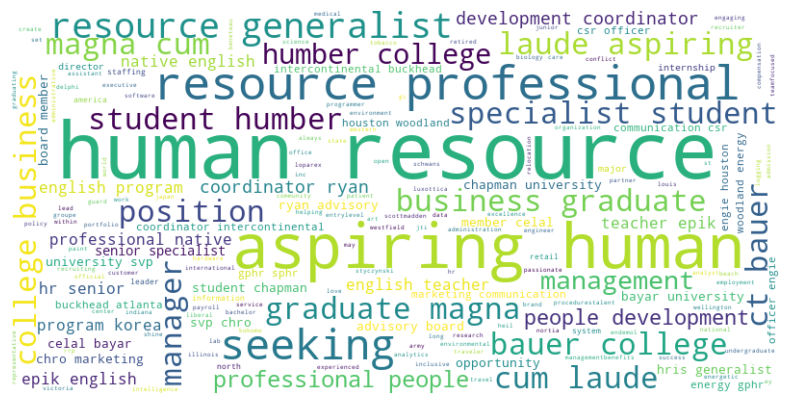

In [11]:
text = " ".join(Data_human["job_title"].dropna().astype(str))

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    stopwords=STOPWORDS
).generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()


- This word cloud shows the words that appear most often in the HR dataset. The biggest words, such as `human resource`, `aspiring human`, `resource professional`, `business graduate`, `seeking position`, and `student`, are the most common, which means they represent the main ideas in the data.

- The results suggest that the dataset mainly contains resumes or profiles from people interested in human resources, especially students, graduates, and early-career applicants. Words like `student`, `graduate`, `college`, and `seeking` show that many of them are looking for job opportunities, while terms like `specialist`, `manager`, and `people development` reflect common HR roles and career interests.

- This also shows that the text includes many general resume phrases rather than specific skills. So, while the word cloud is useful for understanding the overall topic of the dataset, more text cleaning may be needed to remove common expressions and focus on more important terms such as skills, qualifications, and experience.

In [12]:
Data_human.drop('fit', axis=1, inplace=True)

In [13]:
keywords = ['aspiring human resources']
data_Clean_tiile = Data_human.copy()



1. Term frequency-inverse document frequency (TF-IDF)

In the TF-IDF code, the text is converted into numerical vectors based on word frequency. It gives higher importance to words that appear often in one title but not in all titles. Then cosine similarity is used to compare the keyword vector with each job title vector.

In [14]:
vectorizer = TfidfVectorizer()

tfidf_data = data_Clean_tiile.copy()
titles = tfidf_data['job_title'].tolist()

tfidf_title_embs = vectorizer.fit_transform(titles)
tfidf_keyword_embs = vectorizer.transform(keywords)

tfidf_cosine = [cosine_similarity(tfidf_keyword_embs, tfidf_title_emb) for tfidf_title_emb in tfidf_title_embs]
cosine_list = []
for i in tfidf_cosine:
  cosine_list.append(i.item())

tfidf_data['tfidf_fit'] = cosine_list

data = data_Clean_tiile.merge(tfidf_data['tfidf_fit'], how='left', left_index=True, right_index=True)
data.sort_values('tfidf_fit', ascending=False, inplace=True)
data.head(30)

,id,job_title,location,connection,tfidf_fit
2,3,aspiring human resource professional,"Raleigh-Durham, North Carolina Area",44,0.653052
32,33,aspiring human resource professional,"Raleigh-Durham, North Carolina Area",44,0.653052
16,17,aspiring human resource professional,"Raleigh-Durham, North Carolina Area",44,0.653052
20,21,aspiring human resource professional,"Raleigh-Durham, North Carolina Area",44,0.653052
57,58,aspiring human resource professional,"Raleigh-Durham, North Carolina Area",44,0.653052
96,97,aspiring human resource professional,"Kokomo, Indiana Area",71,0.653052
45,46,aspiring human resource professional,"Raleigh-Durham, North Carolina Area",44,0.653052
23,24,aspiring human resource specialist,Greater New York City Area,1,0.598245
59,60,aspiring human resource specialist,Greater New York City Area,1,0.598245
5,6,aspiring human resource specialist,Greater New York City Area,1,0.598245


# 2- GloVe

In [15]:
import torch
glove = torchtext.vocab.GloVe(name='6B', dim=100)

def str_to_glove(str):
  tokens = str.split()
  ind = [glove.stoi[token] for token in tokens if token in glove.stoi]
  vecs = glove.vectors[ind]
  vecs_arr = vecs.numpy()
  embs = vecs_arr.mean(axis=0)
  return embs

glove_data = data_Clean_tiile.copy()
glove_titles = glove_data['job_title'].apply(str_to_glove)
glove_title_embeddings = [title for title in glove_titles]
glove_keywords_embeddings = str_to_glove(keywords[0])

glove_cosines = [cosine_similarity(title_emb.reshape(1,-1), glove_keywords_embeddings.reshape(1,-1))[0,0] for title_emb in glove_title_embeddings]

glove_data['gloVe_fit'] = glove_cosines

glove_data = data.merge(glove_data['gloVe_fit'], how='left', left_index=True, right_index=True)
glove_data.sort_values('gloVe_fit', ascending=False, inplace=True)
glove_data.head(30)

,id,job_title,location,connection,tfidf_fit,gloVe_fit
2,3,aspiring human resource professional,"Raleigh-Durham, North Carolina Area",44,0.653052,0.911811
32,33,aspiring human resource professional,"Raleigh-Durham, North Carolina Area",44,0.653052,0.911811
16,17,aspiring human resource professional,"Raleigh-Durham, North Carolina Area",44,0.653052,0.911811
20,21,aspiring human resource professional,"Raleigh-Durham, North Carolina Area",44,0.653052,0.911811
57,58,aspiring human resource professional,"Raleigh-Durham, North Carolina Area",44,0.653052,0.911811
96,97,aspiring human resource professional,"Kokomo, Indiana Area",71,0.653052,0.911811
45,46,aspiring human resource professional,"Raleigh-Durham, North Carolina Area",44,0.653052,0.911811
72,73,aspiring human resource manager seeking intern...,"Houston, Texas Area",7,0.440985,0.909850
23,24,aspiring human resource specialist,Greater New York City Area,1,0.598245,0.907418
59,60,aspiring human resource specialist,Greater New York City Area,1,0.598245,0.907418


# 3 - Word2Vec

- Word2Vec is a neural network–based method for turning words into vectors. Instead of treating words as isolated symbols, it places them in a continuous space where similar words end up close together. The idea is to capture meaning by looking at how words appear in context. Each word starts with a basic vector (random or one‑hot), and through training, those vectors shift until they reflect real semantic relationships. In the end, Word2Vec gives us embeddings that not only capture grammar but also reveal deeper connections in meaning across the text.

In [16]:
pip install word2vec

  Using cached word2vec-0.11.1.tar.gz (42 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
Failed to build word2vec
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Building wheel for word2vec (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [159 lines of output]
      C:\Users\Dell\AppData\Local\Temp\pip-build-env-6kfzcmm_\overlay\Lib\site-packages\setuptools_scm\_integration\version_inference.py:51: UserWarning: version of word2vec already set
        warnings.warn(self.message)
      C:\Users\Dell\AppData\Local\Temp\pip-build-env-6kfzcmm_\overlay\Lib\site-packages\setuptools\dist.py:765: SetuptoolsDeprecationWarning: License classifiers are deprecated.
      !!
      
              ********************************************************************************
              Please consider removing the following classifiers in favor of a SPDX license expression:
      
              License :: OSI Approved :: Apache Software License
      
              See https://packaging.python.org/en/latest/guides/writing-pyproject-toml/#license for details.
              **********************

In [17]:

def tokenization(str):
  tokens = str.split()
  return tokens

w2vec_data = data_Clean_tiile.copy()
tokens = w2vec_data['job_title'].apply(tokenization).tolist()

w2vec_model = Word2Vec(tokens, vector_size=100, window=5, min_count=2, workers=4)

def str_to_w2v_embedding(str):
  tokens = str.split()
  vecs = [w2vec_model.wv[token] for token in tokens if token in w2vec_model.wv]
  embeddings = np.mean(vecs, axis=0)
  return embeddings

embeddings_w2v = w2vec_data['job_title'].apply(str_to_w2v_embedding)
w2v_list = [embedding for embedding in embeddings_w2v]
keywords_emb = str_to_w2v_embedding(keywords[0])

w2v_cosines = [cosine_similarity(w2v.reshape(1,-1), keywords_emb.reshape(1,-1))[0,0] for w2v in w2v_list]
w2vec_data['w2v_fit'] = w2v_cosines

w2vec = data.merge(w2vec_data['w2v_fit'], left_index=True, right_index=True, how='left')
w2vec.sort_values('w2v_fit', ascending=False, inplace=True)
w2vec.head(30)

NameError: name 'Word2Vec' is not defined

4 FastText (pre-trained)

- FastText, created by Facebook AI Research, builds on Word2Vec but adds a key improvement: it represents words using smaller pieces called subword units (character n‑grams). This means even rare or unseen words can get meaningful embeddings because their vectors are built from shared subword parts. As a result, FastText captures both word meaning and structure, making it especially useful for complex languages and limited datasets.

In [ ]:
pip install fasttext

  Using cached fasttext-0.9.3.tar.gz (73 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached pybind11-3.0.2-py3-none-any.whl.metadata (10 kB)
Using cached pybind11-3.0.2-py3-none-any.whl (310 kB)
Failed to build fasttext
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Building wheel for fasttext (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [48 lines of output]
      C:\Users\Dell\AppData\Local\Temp\pip-build-env-nj_dpwpa\overlay\Lib\site-packages\setuptools\dist.py:599: SetuptoolsDeprecationWarning: Invalid dash-separated key 'description-file' in 'metadata' (setup.cfg), please use the underscore name 'description_file' instead.
      !!
      
              ********************************************************************************
              Usage of dash-separated 'description-file' will not be supported in future
              versions. Please use the underscore name 'description_file' instead.
              (Affected: fasttext).
      
              Available configuration options are listed in:
              https://setuptools.pypa.io/en/latest/userguide/declarative_config.html
      
              This deprecation is overdue, please update your project and remove deprec

2. BERT approach

In the BERT code, each text is converted into contextual embeddings using a pretrained language model. These embeddings represent the meaning of the sentence, not just the individual words. Then cosine similarity is used again to compare the keyword embedding with each job title embedding.